In [ ]:
from itertools import product
from collections import namedtuple

Combo = namedtuple('Combo', ['timeframe', 'asset', 'n'])

parameters = [
    ['H1', 'M1', 'M15'],
    ['XAUUSD', 'US100', 'US500'],
    range(5, 10)
]

# for combo in map(Combo._make, product(*parameters)):
#     print(combo)
#     print(f"Testing {combo.asset} on {combo.timeframe} with n={combo.n}")

parameters = [
    ['H1', 'M1', 'M15'],
    ['XAUUSD', 'US100', 'US500'],
    range(5, 10)
]

for timeframe, asset, n in product(*parameters):
    print(f"Testing {asset} on {timeframe} with n={n}")

# Cumprod vs Normal Monte Carlo

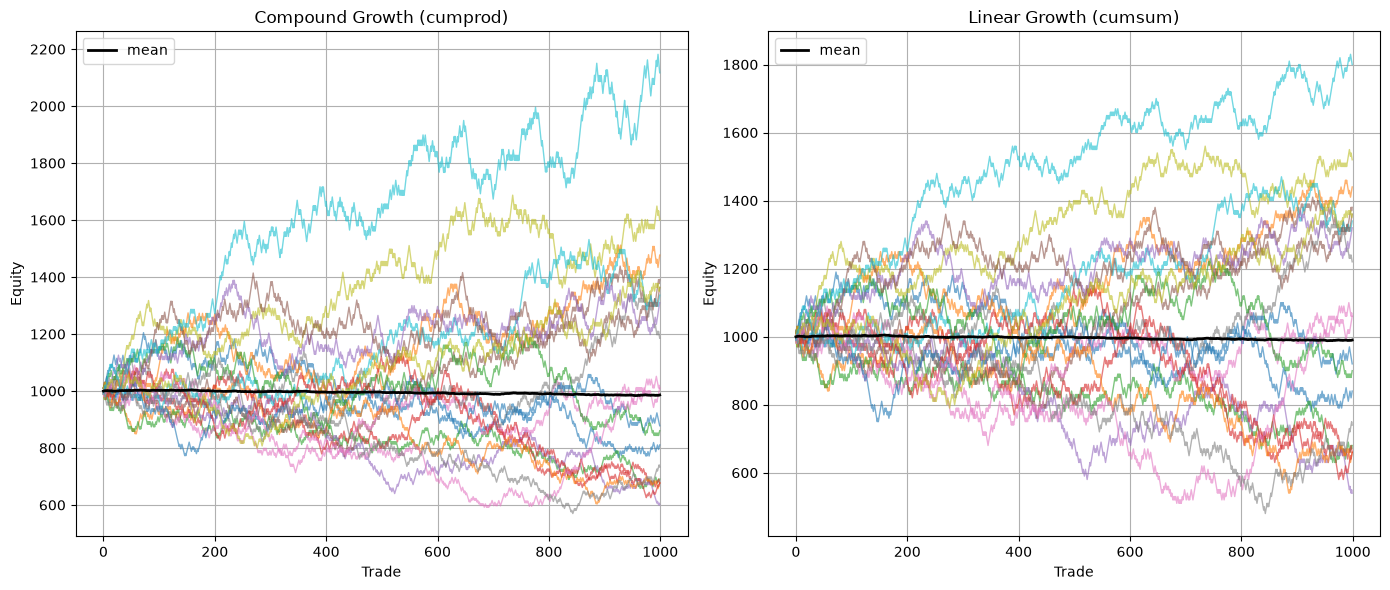

In [11]:
import numpy as np

import matplotlib.pyplot as plt

n_sims = 1_000
n_trades = 1_000
win_prob = 0.5
wins = 1
losses = -1
risk_pct = 0.01
start_equity = 1000.0

rng = np.random.default_rng()

cumprod_eq = []
normal_eq = []

for _ in range(n_sims):
  results = rng.choice([wins, losses], size=n_trades, p=[win_prob, 1 - win_prob])
  returns = results * risk_pct

  cumprod_equity = start_equity * np.cumprod(1 + returns)
  normal_equity = start_equity + np.cumsum(returns) * start_equity

  cumprod_eq.append(cumprod_equity)
  normal_eq.append(normal_equity)

cumprod_eq = np.array(cumprod_eq)
normal_eq = np.array(normal_eq)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Compound growth (cumprod)
for eq in cumprod_eq[:20]:
  ax1.plot(eq, alpha=0.6, linewidth=1)
ax1.plot(cumprod_eq.mean(axis=0), color='black', linewidth=2, label='mean')
ax1.set_xlabel('Trade')
ax1.set_ylabel('Equity')
ax1.set_title('Compound Growth (cumprod)')
ax1.legend()
ax1.grid(True)

# Linear growth (cumsum)
for eq in normal_eq[:20]:
  ax2.plot(eq, alpha=0.6, linewidth=1)
ax2.plot(normal_eq.mean(axis=0), color='black', linewidth=2, label='mean')
ax2.set_xlabel('Trade')
ax2.set_ylabel('Equity')
ax2.set_title('Linear Growth (cumsum)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
pass_rate = (cumprod_eq[:, -1] > start_equity * 1.25).sum() / n_sims * 100
fail_rate = (cumprod_eq[:, -1] < start_equity * 0.90).sum() / n_sims * 100
neutral_rate = 100 - pass_rate - fail_rate

print(f"Pass (>25% profit): {pass_rate:.1f}%")
print(f"Fail (<-10% loss): {fail_rate:.1f}%")
print(f"Neutral: {neutral_rate:.1f}%")

Pass (>25% profit): 17.8%
Fail (<-10% loss): 44.6%
Neutral: 37.6%
